# Notebook 0 — Roadmap

*SWC ENC 2026 · ephys-pop module*

Welcome. Many of you will soon be recording from hundreds of neurons at once with
**Neuropixels probes**, then running a spike sorter — most likely **Kilosort** — to
turn a wall of voltage into sorted spike trains. This module demystifies that black
box. Over the day you'll build **picosort**: a miniature spike sorter, loosely
following the stages of **Kilosort4**, that takes a raw recording all the way to
sorted units. This first notebook has no exercises; it's a map.

## The problem

A Neuropixels probe measures **extracellular voltage** at hundreds of sites along a
thin shank. When a neuron near the probe fires, it produces a tiny (~tens of µV)
biphasic blip that appears — at different amplitudes — on the handful of channels
closest to it. Many neurons fire, their blips overlap in time and space, and the
whole thing sits in noise.

**Spike sorting** is the inverse problem: given only the voltage, recover *which
neuron fired when*. That means (1) cleaning up the signal, (2) detecting spikes,
(3) describing each spike compactly, (4) grouping spikes into **units** (putative
neurons), and (5) resolving overlapping spikes. Kilosort does all of this; picosort
does a simplified, transparent version of each step.

## Why synthetic data?

We generate the recording from a **forward model** whose ground truth we choose:
known neuron positions, known waveforms, known spike times. There's a deep
pedagogical reason — you learn a method best when you can check it against a known
answer. So every stage you build gets tested the same way: *did we recover the
spikes we put in?* At the end we score picosort against the truth, exactly the thing
you can never do on a real recording. That question — recover-the-truth — is the
spine of the module, just as it was in the behaviour unit.

The generator lives in a small backend package, **`picosort`** (imported as `ps`),
which also holds a reference implementation of every stage — so any notebook runs on
its own, and a stuck exercise has a `ps.<name>` fallback to keep you moving.

## The pipeline, notebook by notebook

Every notebook is short and self-contained — a bit of signal processing or
statistics, an exercise or two, a figure at the end — and any stage can be skipped
and left for self-study. The stages chain together into the full picosort pipeline;
Notebook 8 runs the whole thing and grades it against ground truth.

| # | Stage | What you build | What you'll learn |
|---|-------|----------------|-------------------|
| 1 | The recording | probe geometry + the forward model | how a spike spreads across channels; what ground truth looks like |
| 2 | Preprocessing | high-pass filter → common average reference → **whitening** | why filtering and whitening; removing spatial noise correlations |
| 3 | Spike detection | threshold crossings + snippet extraction | thresholds in noise units; aligning and cutting waveforms |
| 4 | Feature extraction | **PCA** on waveforms | dimensionality reduction; why a few components capture spike shape |
| 5 | Clustering → templates | a simple graph/greedy clusterer; **t-SNE** for QC | unsupervised clustering; templates as cluster centroids |
| 6 | Template matching | **matching pursuit** deconvolution | resolving overlapping spikes by iterative peeling |
| 7 | Merging & cleanup | **cross-correlograms** to catch duplicates | refractory periods; over-splitting vs merges |
| 8 | Scoring | match sorted spikes to ground truth | precision/recall, hits/misses; what "good sorting" means |

The Kilosort4 stages we're simplifying are highlighted along the way; the paper is
Pachitariu et al. (2024), *Nature Methods*.

## How the notebooks work

- Each notebook comes in two versions: a **student** copy with `# YOUR CODE HERE`
  blanks, and a **solutions** copy with everything worked out.
- The backend package **`picosort`** generates the synthetic recording and holds
  reference implementations of every stage. Each notebook imports what it needs, so
  you can run any notebook on its own.
- Wherever we can, an exercise ends by **checking your result against ground
  truth**, and tells you roughly what to expect so you can spot a bug.
- **Stuck on an exercise?** Don't let it block your day. Every stage also lives in
  the backend as `ps.<name>` (and fully worked out in the solutions copy), so you can
  drop that in, keep pace, and circle back later.

Run the cell below to confirm your environment is set up (select the
**"SWC Ephys-Pop (.venv)"** kernel if prompted). If it prints a recording's shape
and a plot appears, you're ready for Notebook 1.

environment OK — generated a recording
  traces: (150000, 32) samples x channels, 5.0 s at 30 kHz
  ground truth: 6 units, 183 spikes total


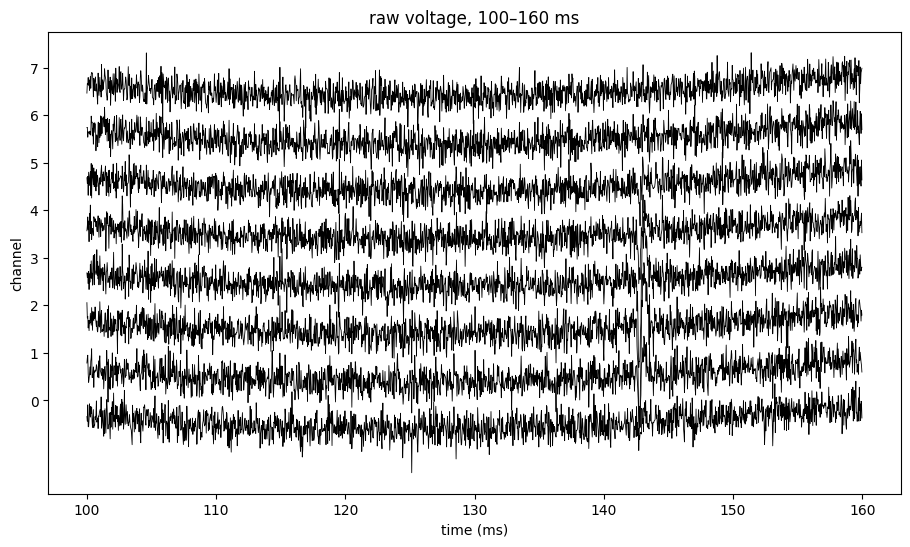

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

# Generate one synthetic recording and take a quick look -- no exercise here,
# just a check that everything is installed and importable.
rec = ps.make_recording(n_units=6, duration_s=5.0, seed=0)
gt = rec.ground_truth
print("environment OK — generated a recording")
print(f"  traces: {rec.traces.shape} samples x channels, {rec.duration_s:.1f} s at {rec.fs/1e3:.0f} kHz")
print(f"  ground truth: {gt.n_units} units, {len(gt.spike_times)} spikes total")

ps.plotting.plot_traces(rec, channels=range(8), t0=0.10, t1=0.16)
plt.show()

## Glossary — terms you'll meet

You don't need these yet; come back when a word trips you up. Each is defined
properly where it first appears (in parentheses).

| term | in plain words |
|---|---|
| **channel / site** | one recording electrode on the probe; it has a position (NB1) |
| **template / footprint** | a unit's stereotyped spike shape across channels and time; the *footprint* is its amplitude per channel (NB1) |
| **unit** | a putative single neuron — a cluster of spikes the sorter believes came from one cell (NB0) |
| **common average reference (CAR)** | subtract the across-channel average to kill shared artefacts (NB2) |
| **high-pass filter** | remove slow (<300 Hz) fluctuations so fast spikes stand out (NB2) |
| **whitening** | de-correlate the noise across channels so a threshold means the same thing everywhere (NB2) |
| **threshold crossing** | a candidate spike: voltage dips past N noise standard deviations (NB3) |
| **snippet / waveform** | the short multi-channel voltage clip cut out around a detected spike (NB3) |
| **PCA / principal component** | a few directions that capture most of the variation in waveform shape (NB4) |
| **feature space** | each spike as a handful of numbers (its PC scores) instead of a full waveform (NB4) |
| **clustering** | grouping spikes with similar features into units, with no labels (NB5) |
| **t-SNE** | a 2-D layout for *eyeballing* whether clusters are well separated (NB5) |
| **matching pursuit** | explain the trace by repeatedly subtracting the best-fitting template (NB6) |
| **cross-correlogram / refractory period** | spike-timing histogram between two units; a real neuron can't fire twice within ~1–2 ms (NB7) |
| **precision / recall** | of the sorted spikes, how many are real; of the real spikes, how many were found (NB8) |

## Ready

That's the whole pipeline: from a wall of voltage to sorted spike trains, every step
checked against a truth you control. On to **Notebook 1**, where we build the
recording itself.